In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_excel(r'E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\数据\眼动数据(转弯合并).xlsx')
df

,阶段,AOI转换次数,静态注释熵(SGE),眼跳注视熵(GTE),组别,性别,受试者,飞行天数
0,巡航,18.0,1.012136,0.642191,Alcohol,女,付瑞晗,1
1,起飞,13.0,1.398246,0.507883,Alcohol,女,付瑞晗,1
2,转弯,10.0,1.344204,0.440657,Alcohol,女,付瑞晗,1
3,降落,14.0,1.089427,0.422709,Alcohol,女,付瑞晗,1
4,巡航,9.0,1.402363,0.385696,Alcohol,女,付瑞晗,2
...,...,...,...,...,...,...,...,...
854,降落,7.0,0.532029,0.106146,Alcohol,男,黄博文,6
855,巡航,23.0,1.872520,0.446616,Alcohol,男,黄博文,7
856,起飞,12.0,1.351165,0.220613,Alcohol,男,黄博文,7
857,转弯,27.5,0.989554,0.332822,Alcohol,男,黄博文,7


In [3]:
df.columns
df.阶段.unique()

array(['巡航', '起飞', '转弯', '降落'], dtype=object)

In [4]:
# 按组别、性别、受试者、飞行天数分组，计算各指标的平均值
df_total = df.groupby(['组别', '性别', '受试者', '飞行天数'], as_index=False).agg({
    'AOI转换次数': 'mean',
    '静态注释熵(SGE)': 'mean',
    '眼跳注视熵(GTE)': 'mean'
})

# 给新的汇总数据加上“阶段=总体”
df_total['阶段'] = '总体'

# 可选：重新排序列的顺序（与原 df 一致）
df_total = df_total[['阶段', 'AOI转换次数', '静态注释熵(SGE)', '眼跳注视熵(GTE)', '组别', '性别', '受试者', '飞行天数']]

# 查看结果
df = df_total
df

,阶段,AOI转换次数,静态注释熵(SGE),眼跳注视熵(GTE),组别,性别,受试者,飞行天数
0,总体,13.750000,1.211003,0.503360,Alcohol,女,付瑞晗,1
1,总体,11.093750,1.317974,0.436600,Alcohol,女,付瑞晗,2
2,总体,11.500000,0.934640,0.401399,Alcohol,女,付瑞晗,3
3,总体,14.505208,0.983144,0.382106,Alcohol,女,付瑞晗,4
4,总体,17.510417,1.031649,0.362813,Alcohol,女,付瑞晗,5
...,...,...,...,...,...,...,...,...
212,总体,13.625000,0.931702,0.462071,Control,男,郭浚杰,3
213,总体,16.875000,1.468918,0.597399,Control,男,郭浚杰,4
214,总体,11.000000,1.101428,0.418697,Control,男,郭浚杰,5
215,总体,11.625000,0.806364,0.209405,Control,男,郭浚杰,6


In [5]:
# # --- 筛选 1~7 天 ---
# df_sub_eye = df[df['飞行天数'].between(1, 7)]
# 
# metrics_eye = ['AOI转换次数', '静态注释熵(SGE)', '眼跳注视熵(GTE)']
# 
# # 存放最终要写入 Excel 的大表
# final_table = []
# 
# for m in metrics_eye:
#     # 计算均值和标准差
#     tmp = df_sub_eye.groupby(['组别', '飞行天数'])[m].agg(['mean', 'std'])
# 
#     # 组合成字符串 "均值 ± 标准差"
#     table_m = (
#             tmp['mean'].round(3).astype(str) +
#             " ± " +
#             tmp['std'].round(3).astype(str)
#     ).unstack('飞行天数')
# 
#     # 在前面插入一行指标名用于区分 blocks
#     table_m.insert(0, '指标', m)
# 
#     final_table.append(table_m)
# 
# # 将三个指标 block 竖向拼接
# final_df = pd.concat(final_table, axis=0)
# 
# # 输出到单个 sheet
# output_path = r"E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\数据\整体数据统计\eye.xlsx"
# with pd.ExcelWriter(output_path) as writer:
#     final_df.to_excel(writer, sheet_name="均值±标准差")
# 
# output_path

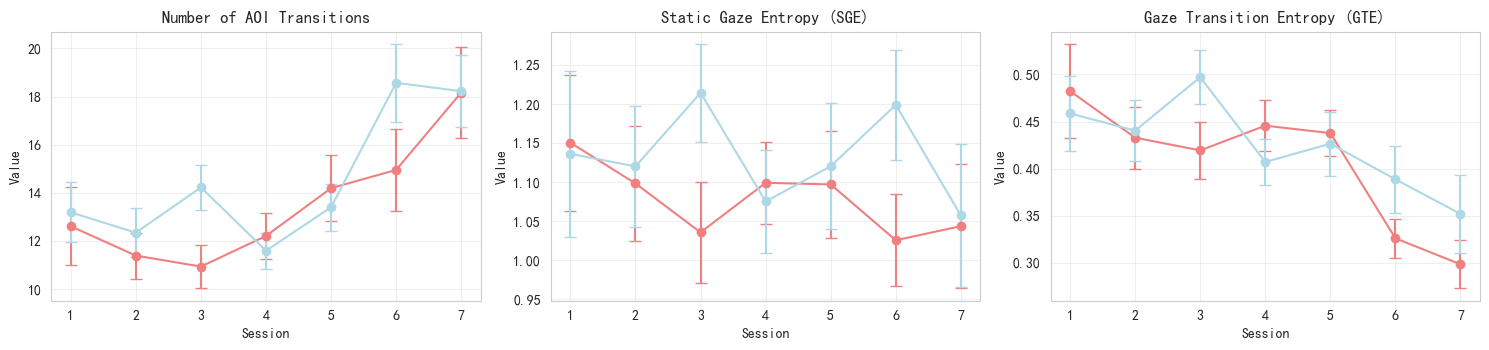

In [6]:
# 要绘制的指标（对应 df 的列名）
metrics = ['AOI转换次数', '静态注释熵(SGE)', '眼跳注视熵(GTE)']

# 自定义标题（显示在图上）
titles = ['Number of AOI Transitions', 'Static Gaze Entropy (SGE)', 'Gaze Transition Entropy (GTE)']

# 创建画布与子图
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

# 定义组别颜色
group_colors = {'Alcohol': 'lightcoral', 'Control': 'lightblue'}

for ax, metric, title in zip(axes, metrics, titles):
    # 计算每组每天的均值和标准误差
    summary = (
        df.groupby(['组别', '飞行天数'])[metric]
        .agg(['mean', 'sem'])
        .reset_index()
    )

    summary['组别'] = summary['组别'].str.strip()

    # 画折线 + 误差棒
    for group_name, group_data in summary.groupby('组别'):
        ax.errorbar(
            group_data['飞行天数'],
            group_data['mean'],
            yerr=group_data['sem'],
            label=group_name,
            marker='o',
            linestyle='-',
            capsize=4,
            color=group_colors.get(group_name, 'black')
        )

    # 固定 X 轴刻度为 1~7
    ax.set_xticks(range(1, 8))
    ax.set_xticklabels(range(1, 8))

    # ✅ 使用自定义标题
    ax.set_title(title)
    ax.set_xlabel('Session')
    ax.set_ylabel('Value')
    ax.grid(alpha=0.3)

# 公共图例
handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, title='组别', loc='upper center', frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.9])  # 右侧留出空间放图例
plt.show()


In [37]:
metrics = ['AOI转换次数', '静态注释熵(SGE)', '眼跳注视熵(GTE)']

for m in metrics:
    # 只取 1~7 天
    df_sub = df[df['飞行天数'].between(1, 7)]

    # 计算均值和标准差
    stat = (
        df_sub
        .groupby(['组别', '飞行天数'])[m]
        .agg(['mean', 'sem'])
        .unstack('飞行天数')
    )

    # 按你指定的顺序取值
    result = pd.DataFrame([
        stat.loc['Alcohol', 'mean'].values,
        stat.loc['Control', 'mean'].values,
        stat.loc['Alcohol', 'sem'].values,
        stat.loc['Control', 'sem'].values
    ])

    print(f'\n===== {m} =====')
    print(result.round(3).to_string(index=False, header=False))



===== AOI转换次数 =====
12.619 11.402 10.947 12.217 14.201 14.959 18.171
13.196 12.354 14.234 11.603 13.411 18.576 18.226
 1.623  0.954  0.911  0.949  1.370  1.694  1.889
 1.249  1.006  0.942  0.742  0.980  1.610  1.500

===== 静态注释熵(SGE) =====
1.151 1.098 1.036 1.099 1.097 1.026 1.044
1.136 1.120 1.215 1.075 1.121 1.199 1.058
0.087 0.073 0.065 0.053 0.068 0.059 0.080
0.107 0.077 0.063 0.066 0.081 0.071 0.091

===== 眼跳注视熵(GTE) =====
0.482 0.433 0.419 0.446 0.438 0.326 0.298
0.459 0.440 0.497 0.407 0.426 0.389 0.352
0.050 0.033 0.030 0.027 0.024 0.020 0.026
0.040 0.032 0.028 0.024 0.034 0.036 0.041


In [9]:
df.columns

Index(['阶段', 'AOI转换次数', '静态注释熵(SGE)', '眼跳注视熵(GTE)', '组别', '性别', '受试者', '飞行天数'], dtype='object')

In [10]:
df3 = pd.read_excel(
    r'E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\数据\GSR_SCL未归一化数据.xlsx')
# df3 = df3[df3['指标'] == 'SCL均值']
df3

,阶段,组别,受试者,飞行天数,SCL均值
0,起飞,Alcohol,付瑞晗,2,6.578167e+05
1,起飞,Alcohol,付瑞晗,3,1.238580e+06
2,起飞,Alcohol,付瑞晗,4,6.835147e+05
3,起飞,Alcohol,付瑞晗,5,1.310422e+06
4,起飞,Alcohol,付瑞晗,6,2.006334e+06
...,...,...,...,...,...
762,静息,Control,陈妍,3,5.928434e+05
763,静息,Control,陈妍,4,1.005811e+06
764,静息,Control,陈妍,5,2.102173e+09
765,静息,Control,陈妍,6,7.993654e+05


In [11]:
# 确保数据按分组+飞行天数排序
df3 = df3.sort_values(['阶段', '组别', '受试者', '飞行天数'])


def interpolate_day1(group):
    # 如果第1天数据缺失：
    if 1 not in group['飞行天数'].values:
        # 用线性回归拟合飞行天数和SCL均值
        x = group['飞行天数']
        y = group['SCL均值']
        # 至少需要两天的数据才可拟合
        if len(group) >= 2:
            coef = np.polyfit(x, y, 1)  # 一阶线性拟合
            scl_day1 = np.polyval(coef, 1)  # 外推第1天
        else:
            scl_day1 = y.mean()  # 如果只有一天，就用那天的值
        # 构造一个新行
        new_row = pd.DataFrame({
            '阶段': [group['阶段'].iloc[0]],
            '组别': [group['组别'].iloc[0]],
            '受试者': [group['受试者'].iloc[0]],
            '飞行天数': [1],
            'SCL均值': [scl_day1]
        })
        group = pd.concat([group, new_row], ignore_index=True)
    return group


df3 = df3.groupby(['阶段', '组别', '受试者'], group_keys=False).apply(interpolate_day1)
df3 = df3.sort_values(['阶段', '组别', '受试者', '飞行天数']).reset_index(drop=True)
df3

,阶段,组别,受试者,飞行天数,SCL均值
0,起飞,Alcohol,付瑞晗,1,7.130677e+05
1,起飞,Alcohol,付瑞晗,2,6.578167e+05
2,起飞,Alcohol,付瑞晗,3,1.238580e+06
3,起飞,Alcohol,付瑞晗,4,6.835147e+05
4,起飞,Alcohol,付瑞晗,5,1.310422e+06
...,...,...,...,...,...
890,静息,Control,陈妍,3,5.928434e+05
891,静息,Control,陈妍,4,1.005811e+06
892,静息,Control,陈妍,5,2.102173e+09
893,静息,Control,陈妍,6,7.993654e+05


In [12]:
df3[df3['受试者'] == '付瑞晗']

,阶段,组别,受试者,飞行天数,SCL均值
0,起飞,Alcohol,付瑞晗,1,7.130677e+05
1,起飞,Alcohol,付瑞晗,2,6.578167e+05
2,起飞,Alcohol,付瑞晗,3,1.238580e+06
3,起飞,Alcohol,付瑞晗,4,6.835147e+05
4,起飞,Alcohol,付瑞晗,5,1.310422e+06
5,起飞,Alcohol,付瑞晗,6,2.006334e+06
6,起飞,Alcohol,付瑞晗,7,9.168047e+05
224,转弯,Alcohol,付瑞晗,1,2.929574e+05
225,转弯,Alcohol,付瑞晗,2,3.259538e+05
226,转弯,Alcohol,付瑞晗,3,2.954999e+05


In [13]:
df3.to_excel(r'E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\数据\插值SCL绘图数据.xlsx', index=False)

In [14]:
df3['阶段'].unique()
# df3.columns

array(['起飞', '转弯', '降落', '静息'], dtype=object)

In [15]:
df1 = df3

df_one1 = df1[(df1['受试者'] == '王子铭') & (df1['飞行天数'] == 4) & (df1['阶段'] == '静息')]

df_one2 = df1[(df1['受试者'] == '董嘉乐') & (df1['飞行天数'] == 4) & (df1['阶段'] == '起飞')]
df3 = df3.drop(df_one1.index)
df3 = df3.drop(df_one2.index)

In [16]:
df1 = df3

df_one3 = df1[(df1['受试者'] == '王子铭') & (df1['飞行天数'] == 4) & (df1['阶段'] == '静息')]
df_one3

,阶段,组别,受试者,飞行天数,SCL均值


In [17]:
df3

,阶段,组别,受试者,飞行天数,SCL均值
0,起飞,Alcohol,付瑞晗,1,7.130677e+05
1,起飞,Alcohol,付瑞晗,2,6.578167e+05
2,起飞,Alcohol,付瑞晗,3,1.238580e+06
3,起飞,Alcohol,付瑞晗,4,6.835147e+05
4,起飞,Alcohol,付瑞晗,5,1.310422e+06
...,...,...,...,...,...
890,静息,Control,陈妍,3,5.928434e+05
891,静息,Control,陈妍,4,1.005811e+06
892,静息,Control,陈妍,5,2.102173e+09
893,静息,Control,陈妍,6,7.993654e+05


In [18]:
df3.to_excel(
    r'E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\付瑞晗单独绘图\数据\分阶段数据\SCL(去除王子铭&董嘉乐第四天某阶段数据).xlsx',
    index=False)

In [19]:
# 对每个组别、受试者、飞行天数汇总各阶段的平均SCL均值
df_total = (
    df3
    .groupby(['组别', '受试者', '飞行天数'], as_index=False)
    .agg({'SCL均值': 'mean'})
)

# 添加阶段列并标记为“总体”
df_total['阶段'] = '总体'

# 调整列顺序（和原始df3一致）
df_total = df_total[['阶段', '组别', '受试者', '飞行天数', 'SCL均值']]

df3 = df_total
df3

,阶段,组别,受试者,飞行天数,SCL均值
0,总体,Alcohol,付瑞晗,1,8.240257e+05
1,总体,Alcohol,付瑞晗,2,8.039972e+05
2,总体,Alcohol,付瑞晗,3,9.611416e+05
3,总体,Alcohol,付瑞晗,4,7.157786e+05
4,总体,Alcohol,付瑞晗,5,1.397072e+06
...,...,...,...,...,...
219,总体,Control,陈妍,3,5.671772e+04
220,总体,Control,陈妍,4,-1.178463e+05
221,总体,Control,陈妍,5,3.825748e+08
222,总体,Control,陈妍,6,-1.736575e+06


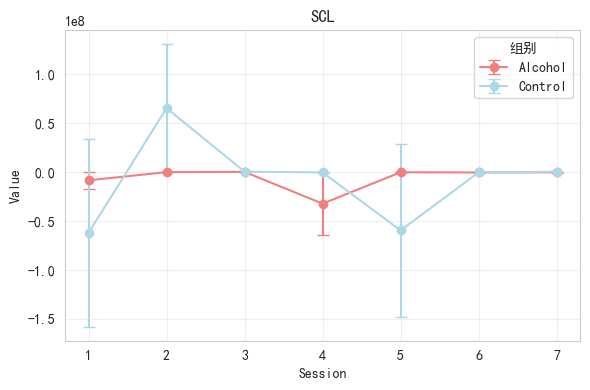

In [20]:
# 指标
metric = 'SCL均值'

# 计算每个组别在不同飞行天数的均值与标准误差
summary = (
    df3.groupby(['组别', '飞行天数'])[metric]
    .agg(['mean', 'sem'])
    .reset_index()
)

plt.figure(figsize=(6, 4))

# 定义组别颜色
group_colors = {'Alcohol': 'lightcoral', 'Control': 'lightblue'}

# group_colors = {'Alcohol': 'red', 'Placebo': 'blue'}

# 每个组别画一条线
for group_name, group_data in summary.groupby('组别'):
    plt.errorbar(
        group_data['飞行天数'],
        group_data['mean'],
        yerr=group_data['sem'],
        label=group_name,
        marker='o',
        linestyle='-',
        capsize=4,
        color=group_colors.get(group_name, 'black')  # 默认黑色
    )

plt.title(f'SCL')
plt.xlabel('Session')
plt.ylabel('Value')

plt.legend(title='组别')
plt.grid(alpha=0.3)

# 设置 y 轴范围
# plt.ylim(-3e8, 3e8)

plt.tight_layout()
plt.show()


In [35]:
# 只取 1~7 天
df_sub = df3[df3['飞行天数'].between(1, 7)]

# 计算均值和标准差
stat = (
    df_sub
    .groupby(['组别', '飞行天数'])['SCL均值']
    .agg(['mean', 'std'])
    .unstack('飞行天数')
)

# 按指定顺序组织结果
result = pd.DataFrame([
    stat.loc['Alcohol', 'mean'].values,
    stat.loc['Control', 'mean'].values,
    stat.loc['Alcohol', 'std'].values,
    stat.loc['Control', 'std'].values
])

# 只输出中间内容（方便复制到 Excel）
print(
    result
    .round(3)
    .to_csv(sep='\t', index=False, header=False)
)



-8246882.925	131100.261	381626.961	-32132494.622	-39287.493	-232518.968	-83718.566
-61965028.891	65540473.131	617686.801	-175651.999	-59484915.428	-185030.669	542847.639
34114875.224	756401.203	1626289.902	128216903.028	727712.465	810463.641	739903.035
383799058.32	260817792.697	2990540.704	593732.389	353209708.248	722292.134	2854579.6



In [23]:
df_eeg = pd.read_excel(r"E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\数据\EEG.xlsx")
df_eeg

,受试者,飞行天数,阶段,组别,性别,delta,theta,alpha,beta,gamma1,gamma2
0,付瑞晗,1,起飞,Alcohol,女,26.615952,5.280793,0.009617,0.076268,68.320034,47.130641
1,付瑞晗,1,转弯,Alcohol,女,2.600909,5.341020,5.116280,1.293847,1.779175,1.236476
2,付瑞晗,1,降落,Alcohol,女,20.133915,39.848839,11.494585,7.412953,91.699839,13.414105
3,付瑞晗,2,起飞,Alcohol,女,0.000110,0.000351,0.000176,16.761637,22.759511,0.000148
4,付瑞晗,2,转弯,Alcohol,女,1.246744,7.490847,0.953912,1.722241,1.624299,1.741540
...,...,...,...,...,...,...,...,...,...,...,...
688,黄博文,6,转弯,Alcohol,男,93.062682,186.030051,292.010177,76.851437,252.582053,863.007011
689,黄博文,6,降落,Alcohol,男,17.043397,9.503600,6.920860,2.201984,1.387406,1.465479
690,黄博文,7,起飞,Alcohol,男,0.110270,0.165917,0.740851,0.886435,0.830895,0.768014
691,黄博文,7,转弯,Alcohol,男,3.411555,1.004419,0.895377,0.693517,1.990672,1.380443


In [24]:
df_eeg.columns
# df_eeg.阶段.unique()

Index(['受试者', '飞行天数', '阶段', '组别', '性别', 'delta', 'theta', 'alpha', 'beta',
       'gamma1', 'gamma2'],
      dtype='object')

In [25]:
# 对每个受试者、飞行天数、组别、性别计算三个阶段的均值
df_eeg_total = (
    df_eeg
    .groupby(['受试者', '飞行天数', '组别', '性别'], as_index=False)
    .agg({
        'delta': 'mean',
        'theta': 'mean',
        'alpha': 'mean',
        'beta': 'mean',
        'gamma1': 'mean',
        'gamma2': 'mean'
    })
)

# 添加“阶段=总体”列
df_eeg_total['阶段'] = '总体'

# 调整列顺序与原df一致
df_eeg_total = df_eeg_total[['受试者', '飞行天数', '阶段', '组别', '性别',
                             'delta', 'theta', 'alpha', 'beta', 'gamma1', 'gamma2']]

df_eeg = df_eeg_total
df_eeg

,受试者,飞行天数,阶段,组别,性别,delta,theta,alpha,beta,gamma1,gamma2
0,付瑞晗,1,总体,Alcohol,女,16.450259,16.823551,5.540161,2.927690,53.933016,20.593741
1,付瑞晗,2,总体,Alcohol,女,1.121760,7.148081,13.401945,47.456428,15.787266,5.106887
2,付瑞晗,3,总体,Alcohol,女,35.342766,19.849987,84.488681,20.144325,58.525234,87.378977
3,付瑞晗,4,总体,Alcohol,女,55.451488,72.071825,32.869491,4.147350,42.149440,37.387751
4,付瑞晗,5,总体,Alcohol,女,31.596968,7.485900,17.305328,2.020948,1.077719,32.019395
...,...,...,...,...,...,...,...,...,...,...,...
226,黄博文,3,总体,Alcohol,男,10.732426,14.220796,10.915524,10.138052,16.677451,19.299874
227,黄博文,4,总体,Alcohol,男,6.538456,5.461182,5.388626,3.521250,7.568547,6.909196
228,黄博文,5,总体,Alcohol,男,0.522254,0.530007,1.070445,1.159354,0.883894,1.049924
229,黄博文,6,总体,Alcohol,男,36.750573,65.360850,99.863961,26.471411,84.835314,288.447975


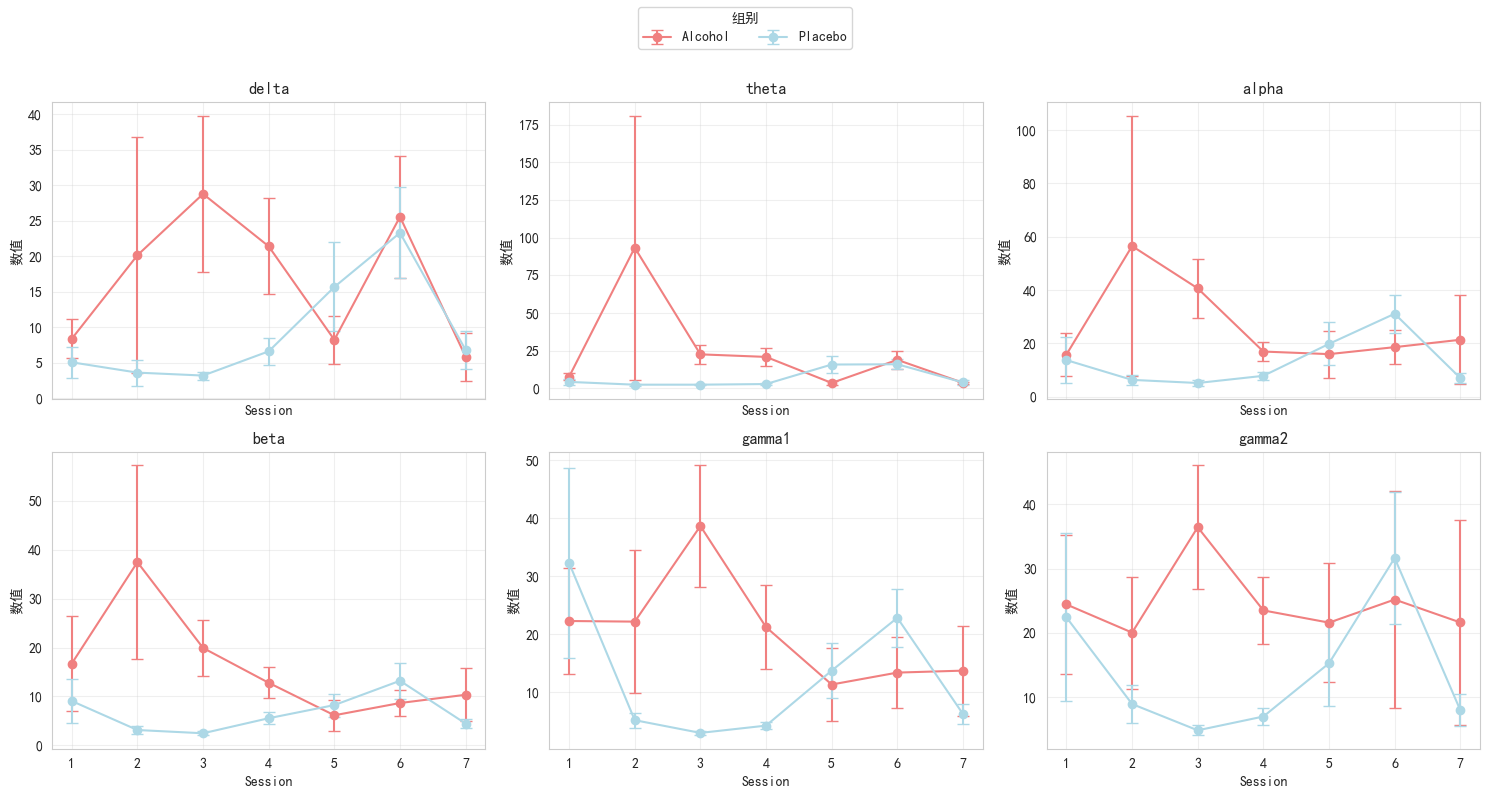

In [26]:
# EEG 频段指标
metrics = ['delta', 'theta', 'alpha', 'beta', 'gamma1', 'gamma2']

# 创建 2x3 子图
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

# 将二维 axes 展平成一维，方便循环
axes = axes.flatten()

# 定义组别颜色
group_colors = {'Alcohol': 'lightcoral', 'Placebo': 'lightblue'}

for ax, metric in zip(axes, metrics):
    # 计算每组在不同飞行天数的均值和标准误差
    summary = (
        df_eeg.groupby(['组别', '飞行天数'])[metric]
        .agg(['mean', 'sem'])
        .reset_index()
    )

    # 每个组别画折线 + 误差棒
    for group_name, group_data in summary.groupby('组别'):
        ax.errorbar(
            group_data['飞行天数'],
            group_data['mean'],
            yerr=group_data['sem'],
            label=group_name,
            marker='o',
            linestyle='-',
            capsize=4,
            color=group_colors.get(group_name, 'black')  # 默认黑色
        )

    ax.set_title(metric)
    ax.set_xlabel('Session')
    ax.set_ylabel('数值')
    ax.grid(alpha=0.3)

# 删除多余空白子图（如果指标数 < 6 可启用）
for i in range(len(metrics), len(axes)):
    fig.delaxes(axes[i])

# 公共图例（放在整张图上方）
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='组别', loc='upper center', ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.92])  # 给图例留空间
plt.show()


In [38]:
df_fs = pd.read_excel(
    r'E:\pycharm all files\眼动数据处理\绘图\不归一化绘图\数据\整体飞行得分数据.xlsx')
df_fs.rename(columns={'Unnamed: 0': 'Unnamed'}, inplace=True)

In [39]:
df_fs.columns
df_fs.Unnamed.unique()

array(['Alcohol', 'Placebo', 'Alcohol_se', 'Placebo_se'], dtype=object)

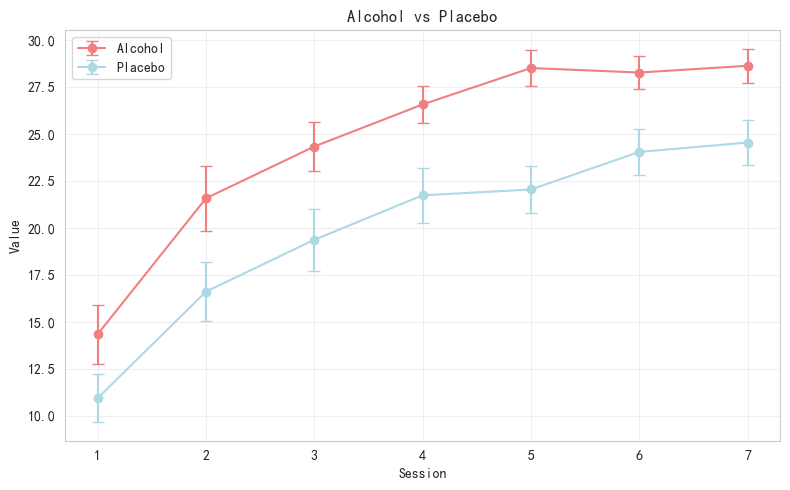

In [40]:
# 设置横轴（Session 或 飞行天数）
x = df_fs.columns[1:]  # [1, 2, 3, 4, 5, 6, 7]

# 获取各组数据
alcohol_mean = df_fs[df_fs['Unnamed'] == 'Alcohol'].iloc[0, 1:].values.astype(float)
alcohol_se = df_fs[df_fs['Unnamed'] == 'Alcohol_se'].iloc[0, 1:].values.astype(float)

placebo_mean = df_fs[df_fs['Unnamed'] == 'Placebo'].iloc[0, 1:].values.astype(float)
placebo_se = df_fs[df_fs['Unnamed'] == 'Placebo_se'].iloc[0, 1:].values.astype(float)

# 绘图
plt.figure(figsize=(8, 5))

# Alcohol 折线 + errorbar
plt.errorbar(x, alcohol_mean, yerr=alcohol_se, marker='o', linestyle='-', capsize=4, label='Alcohol',
             color='lightcoral')
# color='lightcoral'
# Placebo 折线 + errorbar
plt.errorbar(x, placebo_mean, yerr=placebo_se, marker='o', linestyle='-', capsize=4, label='Placebo',
             color='lightblue')
# color='lightblue'
plt.xlabel('Session')
plt.ylabel('Value')
plt.title('Alcohol vs Placebo')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# 按顺序取出 4 行 × 7 天的数据
result = pd.DataFrame([
    df_fs[df_fs['Unnamed'] == 'Alcohol'].iloc[0, 1:].astype(float).values,
    df_fs[df_fs['Unnamed'] == 'Placebo'].iloc[0, 1:].astype(float).values,
    df_fs[df_fs['Unnamed'] == 'Alcohol_se'].iloc[0, 1:].astype(float).values,
    df_fs[df_fs['Unnamed'] == 'Placebo_se'].iloc[0, 1:].astype(float).values
])

# 输出纯数值（可直接复制到 Excel）
print(
    result
    .round(3)
    .to_csv(sep='\t', index=False, header=False)
)


14.35	21.59	24.35	26.59	28.53	28.29	28.65
10.94	16.62	19.38	21.75	22.06	24.06	24.56
1.581	1.719	1.331	0.985	0.971	0.861	0.895
1.27	1.581	1.643	1.47	1.266	1.213	1.218

